# ❤️ Heart Disease Prediction
**Super AI Engineer Season 6 — Data Science Track**

### โจทย์
- Predict ว่าคนไข้มีประวัติโรคหัวใจหรือไม่ (Yes/No)
- Train: 223,084 rows | Test: 74,361 rows
- Metric: **F2-score** → recall สำคัญกว่า precision 2 เท่า

### Pipeline
1. Setup & Load Data
2. EDA
3. Preprocessing + Feature Engineering
4. Train Model (FLAML AutoML + Optuna Tuning)
5. Threshold Tuning
6. Predict & Submit

## 1. Setup & Load Data

In [ ]:
# === Install Libraries ===
# FLAML  : AutoML — ลอง model หลายตัวอัตโนมัติ หา best model + params
# Optuna : Hyperparameter tuning อัตโนมัติต่อจาก FLAML
!pip install flaml[lgbm] optuna lightgbm -q
print('Libraries installed ✅')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 23.6 MB/s eta 0:00:00
Libraries installed ✅


In [ ]:
# === Mount Google Drive ===
# ไฟล์ train.csv / test.csv / sample_submission.csv
# ต้องอัปโหลดไว้ใน Google Drive ก่อน แล้วแก้ FOLDER_PATH ด้านล่าง
from google.colab import drive
drive.mount('/content/drive')

# ⚙️ แก้ path นี้ให้ตรงกับที่เก็บไฟล์ใน Drive
FOLDER_PATH = '/content/drive/MyDrive/superai-ss6/heart-disease'

print(f'Drive mounted ✅')
print(f'Data folder : {FOLDER_PATH}')

Mounted at /content/drive
Drive mounted ✅
Data folder : /content/drive/MyDrive/superai-ss6/heart-disease


In [ ]:
# === Import Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import fbeta_score, classification_report
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # ปิด log ของ Optuna

from flaml import AutoML

print('Libraries loaded ✅')

Libraries loaded ✅


In [ ]:
# === Load Data ===
# อ่านไฟล์จาก Google Drive ตาม FOLDER_PATH ที่กำหนดไว้ด้านบน
train      = pd.read_csv(f'{FOLDER_PATH}/train.csv')
test       = pd.read_csv(f'{FOLDER_PATH}/test.csv')
sample_sub = pd.read_csv(f'{FOLDER_PATH}/sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Sample sub  : {sample_sub.shape}')

Train shape : (223084, 20)
Test shape  : (74361, 19)
Sample sub  : (74361, 2)


## 2. EDA (Exploratory Data Analysis)

In [ ]:
# === ดูตัวอย่างข้อมูล ===
train.head(3)

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes


In [ ]:
# === ดู Data Types และ Missing Values ===
print('=== Missing Values (Train) ===')
missing = train.isnull().sum()
print(missing[missing > 0])

print('\n=== Missing Values (Test) ===')
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0])

=== Missing Values (Train) ===
History of HeartDisease or Attack     1694
Told High Cholesterol                32186
Body Mass Index                      11782
Smoked 100+ Cigarettes                   1
Diagnosed Diabetes                       3
Doctor Visit Cost Barrier                1
General Health                           1
Difficulty Walking                       3
dtype: int64

=== Missing Values (Test) ===
Series([], dtype: int64)


Target Distribution:
History of HeartDisease or Attack
No     203322
Yes     18068
Name: count, dtype: int64

Positive Rate: 8.2%


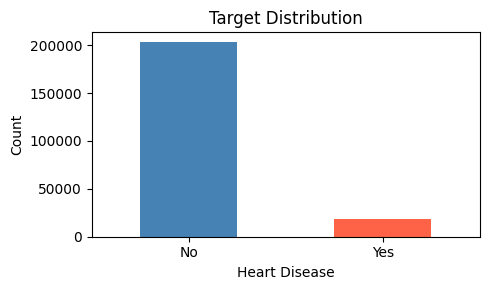

In [ ]:
# === Target Distribution ===
# โรคหัวใจ imbalanced มาก — สำคัญต่อการเลือก metric และ threshold
target_col = 'History of HeartDisease or Attack'
target_counts = train[target_col].value_counts()
print('Target Distribution:')
print(target_counts)
print(f'\nPositive Rate: {target_counts["Yes"] / target_counts.sum() * 100:.1f}%')

# Plot
fig, ax = plt.subplots(figsize=(5, 3))
target_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel('Heart Disease')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# === ดู Unique Values ของ Categorical Columns ===
# เพื่อเข้าใจว่าแต่ละ column มีค่าอะไรบ้าง ก่อน encode
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['ID', target_col]]

for col in cat_cols:
    print(f'{col}: {train[col].unique().tolist()}')

High Blood Pressure: ['Yes', 'No']
Told High Cholesterol: ['Yes', 'No', nan]
Cholesterol Checked: ['Yes', 'No']
Smoked 100+ Cigarettes: ['Yes', 'No', nan]
Diagnosed Stroke: ['No', 'Yes']
Diagnosed Diabetes: ['No', 'Yes', nan]
Leisure Physical Activity: ['No', 'Yes']
Heavy Alcohol Consumption: ['No', 'Yes']
Health Care Coverage: ['Yes', 'No']
Doctor Visit Cost Barrier: ['No', 'Yes', nan]
General Health: ['Very Poor', 'Fair', 'Good', 'Poor', 'Excellent', nan]
Difficulty Walking: ['Yes', 'No', nan]
Sex: ['Female', 'Male']
Education Level: ['High school graduate', 'College graduate', 'Some high school', 'Some college or technical school', 'Elementary', 'Never attended school']
Income Level: ['$15,000 to less than $20,000', 'Less than $10,000', '$75,000 or more', '$35,000 to less than $50,000', '$20,000 to less than $25,000', '($10,000 to less than $15,000', '$50,000 to less than $75,000', '$25,000 to less than $35,000']
Vegetable or Fruit Intake (1+ per Day): ['Yes', 'No']


## 3. Preprocessing

In [ ]:
# === กำหนด Column Types ===

# Binary columns: Yes/No → 1/0
binary_cols = [
    'High Blood Pressure',
    'Told High Cholesterol',
    'Cholesterol Checked',
    'Smoked 100+ Cigarettes',
    'Diagnosed Stroke',
    'Diagnosed Diabetes',
    'Leisure Physical Activity',
    'Heavy Alcohol Consumption',
    'Health Care Coverage',
    'Doctor Visit Cost Barrier',
    'Difficulty Walking',
    'Vegetable or Fruit Intake (1+ per Day)',
]

# Sex column: Male/Female → 1/0
sex_col = 'Sex'

# Ordinal columns: ต้อง map ตามลำดับความหมาย (ไม่ใช่ one-hot)
ordinal_maps = {
    'General Health': {
        'Very Poor': 1, 'Poor': 2, 'Fair': 3, 'Good': 4, 'Excellent': 5
    },
    'Education Level': {
        'Never attended school': 1,
        'Elementary': 2,
        'Some high school': 3,
        'High school graduate': 4,
        'Some college or technical school': 5,
        'College graduate': 6,
    },
    'Income Level': {
        'Less than $10,000': 1,
        '($10,000 to less than $15,000': 2,
        '$15,000 to less than $20,000': 3,
        '$20,000 to less than $25,000': 4,
        '$25,000 to less than $35,000': 5,
        '$35,000 to less than $50,000': 6,
        '$50,000 to less than $75,000': 7,
        '$75,000 or more': 8,
    }
}

# Numerical: ใช้ตามเดิม
num_col = 'Body Mass Index'
age_col = 'Age'

print('Column types defined ✅')

Column types defined ✅


In [ ]:
# === Preprocessing Function ===
# สร้างเป็น function เพื่อใช้กับทั้ง train และ test

def preprocess(df, is_train=True):
    df = df.copy()

    # --- 1. Binary columns: Yes → 1, No → 0 ---
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0})
            # fill missing ด้วย mode (0 = No) เพราะส่วนใหญ่คือ No
            df[col] = df[col].fillna(df[col].mode()[0])

    # --- 2. Sex: Female → 0, Male → 1 ---
    df[sex_col] = df[sex_col].map({'Female': 0, 'Male': 1})
    df[sex_col] = df[sex_col].fillna(0)

    # --- 3. Ordinal columns ---
    for col, mapping in ordinal_maps.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)
            # fill missing ด้วย median
            df[col] = df[col].fillna(df[col].median())

    # --- 4. BMI: fill missing ด้วย median ---
    df[num_col] = df[num_col].fillna(df[num_col].median())

    # --- 5. Age: ใช้ตามเดิม (เป็น int อยู่แล้ว) ---
    # ไม่ต้องทำอะไรเพิ่ม

    return df

# Apply preprocessing
train_processed = preprocess(train, is_train=True)
test_processed  = preprocess(test,  is_train=False)

print('Preprocessing done ✅')
print(f'Missing values remaining (train): {train_processed.isnull().sum().sum()}')
print(f'Missing values remaining (test) : {test_processed.isnull().sum().sum()}')

Preprocessing done ✅
Missing values remaining (train): 1694
Missing values remaining (test) : 0


In [ ]:
# === Feature Engineering ===
# เพิ่ม interaction features ที่มีความสัมพันธ์กับโรคหัวใจสูง

def add_features(df):
    df = df.copy()

    # Risk Score: นับจำนวน risk factors หลักๆ รวมกัน
    # คนที่มี risk factor เยอะ → โอกาสเป็นโรคหัวใจสูง
    df['Risk_Score'] = (
        df['High Blood Pressure'] +
        df['Diagnosed Diabetes'] +
        df['Diagnosed Stroke'] +
        df['Smoked 100+ Cigarettes'] +
        df['Difficulty Walking']
    )

    # BMI Category: แบ่ง BMI เป็น 4 กลุ่ม
    # Obese มีความสัมพันธ์กับโรคหัวใจสูงมาก
    df['BMI_Category'] = pd.cut(
        df['Body Mass Index'],
        bins=[0, 18.5, 25, 30, 100],
        labels=[1, 2, 3, 4]
    ).astype(float)

    # Age × High Blood Pressure: คนแก่ + ความดันสูง = risk สูงมาก
    df['Age_BP'] = df['Age'] * df['High Blood Pressure']

    # Age × Diabetes
    df['Age_Diabetes'] = df['Age'] * df['Diagnosed Diabetes']

    # General Health × Difficulty Walking
    df['Health_Walk'] = df['General Health'] * df['Difficulty Walking']

    return df

train_processed = add_features(train_processed)
test_processed  = add_features(test_processed)
print('Feature engineering done ✅')

# === แยก Features และ Target ===
TARGET = 'History of HeartDisease or Attack'
ID_COL = 'ID'

# Feature columns = ทุก column ยกเว้น ID และ Target
feature_cols = [c for c in train_processed.columns if c not in [ID_COL, TARGET]]

X      = train_processed[feature_cols]
y      = train_processed[TARGET].map({'Yes': 1, 'No': 0})
X_test = test_processed[feature_cols]

# Drop rows ที่ target เป็น NaN (1,694 rows)
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Features     : {len(feature_cols)} ({len(feature_cols)-5} original + 5 new)')

Feature engineering done ✅
X shape      : (221390, 23)
y shape      : (221390,)
X_test shape : (74361, 23)
Features     : 23 (18 original + 5 new)


## 4. Train Model

ใช้ 2 ขั้นตอน:
1. **FLAML AutoML** — ลอง model หลายตัวอัตโนมัติ หา best model + params เบื้องต้น
2. **Optuna** — fine-tune hyperparameters ของ LightGBM ต่อจาก FLAML

In [ ]:
# === Train/Validation Split ===
# stratify=y เพื่อให้สัดส่วน class เท่ากันใน train และ val
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Val size   : {X_val.shape[0]:,}')

Train size : 177,112
Val size   : 44,278


In [ ]:
# === Step 1: FLAML AutoML ===
# FLAML จะลอง LightGBM, XGBoost, RandomForest ฯลฯ อัตโนมัติ
# แล้วเลือก model + params ที่ดีที่สุดภายใน time_budget ที่กำหนด

automl = AutoML()

automl.fit(
    X_train, y_train,
    task            = 'classification',
    metric          = 'f1',           # ไม่มี f2 ใน FLAML ใช้ f1 แล้วค่อย tune threshold
    time_budget     = 300,            # วินาที — เพิ่มได้ถ้ามีเวลา (600 = 10 นาที)
    eval_method     = 'holdout',      # เร็วกว่า cv สำหรับ dataset ใหญ่
    split_ratio     = 0.2,
    sample_weight   = (y_train == 1).map({True: 10, False: 1}),  # เพิ่ม weight ให้ positive class
    verbose         = 1
)

print(f'\n✅ Best model   : {automl.best_estimator}')
print(f'Best F1 (val)  : {automl.best_loss:.4f}')
print(f'Best config    : {automl.best_config}')

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



✅ Best model   : sgd
Best F1 (val)  : 0.2144
Best config    : {'penalty': np.str_('None'), 'alpha': np.float64(0.05107571869444682), 'l1_ratio': np.float64(0.00014928393201501985), 'epsilon': np.float64(0.021055135803587276), 'learning_rate': np.str_('constant'), 'eta0': np.float64(0.018217130957424905), 'power_t': np.float64(0.5589303178139401), 'average': False, 'loss': np.str_('modified_huber')}


In [ ]:
# === Step 2: Optuna Fine-tuning ===
# ใช้ params จาก FLAML เป็น starting point แล้ว tune ต่อ
# เป้าหมาย: maximize F2-score โดยตรง (ซึ่ง FLAML ทำไม่ได้)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # scale_pos_weight: tune ด้วย — บังคับให้ model bias toward positive
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 5.0, 20.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set  = [(X_val, y_val)],
        callbacks = [
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=-1)  # ปิด log
        ]
    )

    # Predict probability แล้วหา threshold ที่ให้ F2 สูงสุด
    val_proba  = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.05, 0.5, 0.005)
    best_f2    = max(
        fbeta_score(y_val, (val_proba >= t).astype(int), beta=2, zero_division=0)
        for t in thresholds
    )
    return best_f2


# รัน Optuna — n_trials ยิ่งมากยิ่งดี แต่ใช้เวลานานขึ้น
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Best F2 (Optuna) : {study.best_value:.4f}')
print(f'Best params        : {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best F2 (Optuna) : 0.5379
Best params        : {'n_estimators': 676, 'learning_rate': 0.010915263384187518, 'num_leaves': 236, 'min_child_samples': 43, 'subsample': 0.7764003719226976, 'colsample_bytree': 0.7237000304064256, 'scale_pos_weight': 8.810948672782732}


In [ ]:
# === Train Final Model ด้วย Best Params จาก Optuna ===
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'Final model trained ✅  (best iter: {final_model.best_iteration_})')

Final model trained ✅  (best iter: 23)


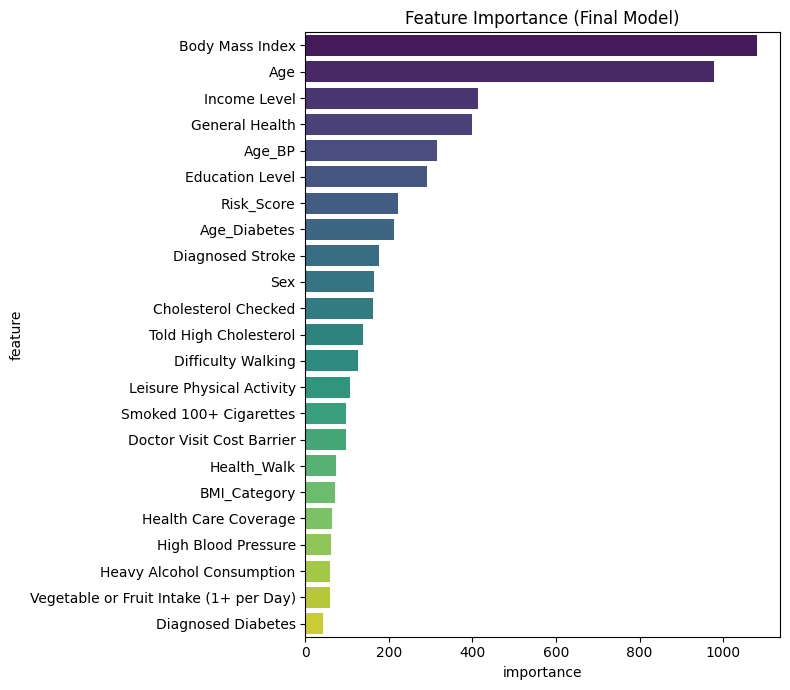

In [ ]:
# === Feature Importance ===
feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Feature Importance (Final Model)')
plt.tight_layout()
plt.show()

## 5. Threshold Tuning

เนื่องจาก metric คือ **F2-score** ซึ่งให้น้ำหนัก recall มากกว่า precision
→ ต้อง lower threshold ให้ model predict positive มากขึ้น
→ Default 0.5 ไม่ใช่ optimal สำหรับ F2

Best Threshold : 0.17
Best F2-score  : 0.5370


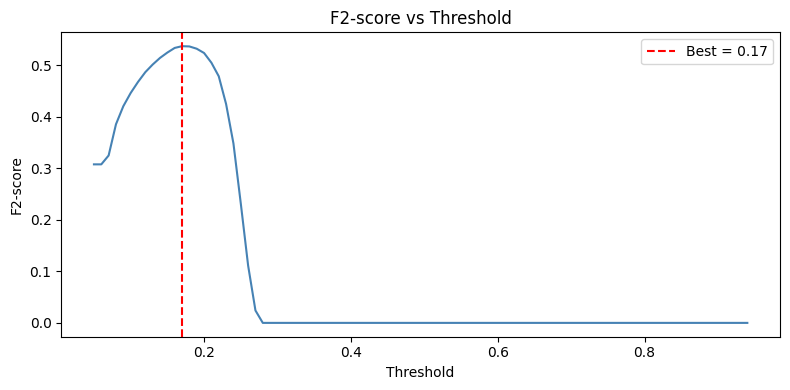

In [ ]:
# === Predict Probability บน Validation Set ===
val_proba = final_model.predict_proba(X_val)[:, 1]  # probability ของ class 1 (Yes)

# === Loop หา Optimal Threshold ===
thresholds = np.arange(0.05, 0.95, 0.01)
f2_scores  = []

for thresh in thresholds:
    y_pred = (val_proba >= thresh).astype(int)
    f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
    f2_scores.append(f2)

# หา threshold ที่ให้ F2 สูงสุด
best_idx       = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2        = f2_scores[best_idx]

print(f'Best Threshold : {best_threshold:.2f}')
print(f'Best F2-score  : {best_f2:.4f}')

# Plot F2 vs Threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f2_scores, color='steelblue')
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Best = {best_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F2-score')
ax.set_title('F2-score vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# === Evaluate บน Validation Set ด้วย Best Threshold ===
y_val_pred = (val_proba >= best_threshold).astype(int)

print('=== Validation Report ===')
print(classification_report(y_val, y_val_pred, target_names=['No', 'Yes']))

val_f2 = fbeta_score(y_val, y_val_pred, beta=2)
print(f'Validation F2-score: {val_f2:.4f}')

=== Validation Report ===
              precision    recall  f1-score   support

          No       0.98      0.77      0.86     40664
         Yes       0.24      0.79      0.36      3614

    accuracy                           0.77     44278
   macro avg       0.61      0.78      0.61     44278
weighted avg       0.92      0.77      0.82     44278

Validation F2-score: 0.5370


## 6. Predict & Submit

In [ ]:
# === Predict บน Test Set ===
test_proba = final_model.predict_proba(X_test)[:, 1]  # probability
test_pred  = (test_proba >= best_threshold).astype(int)  # apply best threshold

# แปลง 1/0 กลับเป็น Yes/No
test_pred_label = pd.Series(test_pred).map({1: 'Yes', 0: 'No'})

print(f'Predicted Yes: {(test_pred == 1).sum():,}')
print(f'Predicted No : {(test_pred == 0).sum():,}')
print(f'Positive Rate: {(test_pred == 1).mean()*100:.1f}%')

Predicted Yes: 23,415
Predicted No : 50,946
Positive Rate: 31.5%


In [ ]:
# === สร้าง Submission File ===
submission = pd.DataFrame({
    'ID'                              : test[ID_COL].values,
    'History of HeartDisease or Attack': test_pred_label.values
})

# ตรวจสอบ format ให้ตรงกับ sample_submission
print('=== Submission Preview ===')
print(submission.head())
print(f'\nShape: {submission.shape}')  # ต้องเป็น (74361, 2)
print(f'Columns: {submission.columns.tolist()}')
print(f'Null values: {submission.isnull().sum().sum()}')

=== Submission Preview ===
            ID History of HeartDisease or Attack
0  test_000001                                No
1  test_000002                                No
2  test_000003                               Yes
3  test_000004                                No
4  test_000005                                No

Shape: (74361, 2)
Columns: ['ID', 'History of HeartDisease or Attack']
Null values: 0


In [ ]:
# === Save Submission ===
# 1. Save ไว้ใน Colab session (download ได้จาก Files panel ด้านซ้าย)
submission.to_csv('submission.csv', index=False)

# 2. Save กลับไปที่ Google Drive ด้วย (ไม่หายเมื่อ session หมด)
submission.to_csv(f'{FOLDER_PATH}/submission.csv', index=False)

# 3. Download ไฟล์ลงเครื่องทันที
from google.colab import files
files.download('submission.csv')

print('submission.csv saved ✅')
print(f'Saved to Drive : {FOLDER_PATH}/submission.csv')
print('\nReady to submit on Kaggle! 🚀')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

submission.csv saved ✅
Saved to Drive : /content/drive/MyDrive/superai-ss6/heart-disease/submission.csv

Ready to submit on Kaggle! 🚀
